In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from google.colab import files

uploaded = files.upload()

Saving Unemployment in India.csv to Unemployment in India.csv


In [3]:
df = pd.read_csv('Unemployment in India.csv')

In [4]:
df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


In [5]:
print(df.shape)
print(df.columns)
print(df.info())

(768, 7)
Index(['Region', ' Date', ' Frequency', ' Estimated Unemployment Rate (%)',
       ' Estimated Employed', ' Estimated Labour Participation Rate (%)',
       'Area'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    740 non-null    object 
 1    Date                                     740 non-null    object 
 2    Frequency                                740 non-null    object 
 3    Estimated Unemployment Rate (%)          740 non-null    float64
 4    Estimated Employed                       740 non-null    float64
 5    Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                      740 non-null    object 
dtypes: float64(3), object(4)
memory usage: 42.1+ KB
None


In [6]:
df.isnull().sum()

,0
Region,28
Date,28
Frequency,28
Estimated Unemployment Rate (%),28
Estimated Employed,28
Estimated Labour Participation Rate (%),28
Area,28


In [7]:
df = df.dropna()

In [8]:
df.describe()

,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%)
count,740.000000,7.400000e+02,740.000000
mean,11.787946,7.204460e+06,42.630122
std,10.721298,8.087988e+06,8.111094
min,0.000000,4.942000e+04,13.330000
25%,4.657500,1.190404e+06,38.062500
50%,8.350000,4.744178e+06,41.160000
75%,15.887500,1.127549e+07,45.505000
max,76.740000,4.577751e+07,72.570000


In [13]:
df.columns = df.columns.str.strip()

print(df.columns)

Index(['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)',
       'Estimated Employed', 'Estimated Labour Participation Rate (%)',
       'Area'],
      dtype='object')


In [14]:
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

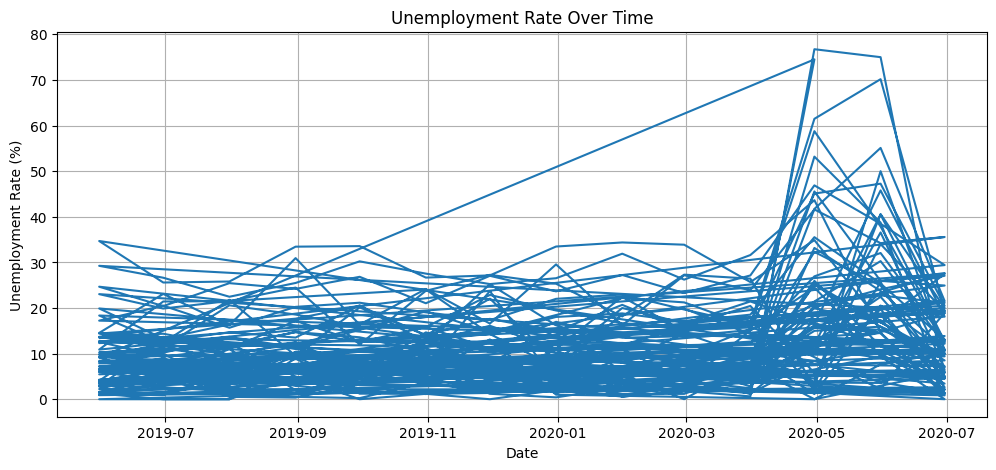

In [18]:
plt.figure(figsize=(12,5))

plt.plot(
    df['Date'],
    df['Estimated Unemployment Rate (%)']
)

plt.title("Unemployment Rate Over Time")
plt.xlabel("Date")
plt.ylabel("Unemployment Rate (%)")
plt.grid()

plt.show()

In [19]:
state_unemployment = df.groupby('Region')[
    'Estimated Unemployment Rate (%)'
].mean()

state_unemployment.sort_values(
    ascending=False
).head(10)

,Estimated Unemployment Rate (%)
Region,
Tripura,28.350357
Haryana,26.283214
Jharkhand,20.585000
Bihar,18.918214
Himachal Pradesh,18.540357
Delhi,16.495357
Jammu & Kashmir,16.188571
Chandigarh,15.991667
Rajasthan,14.058214


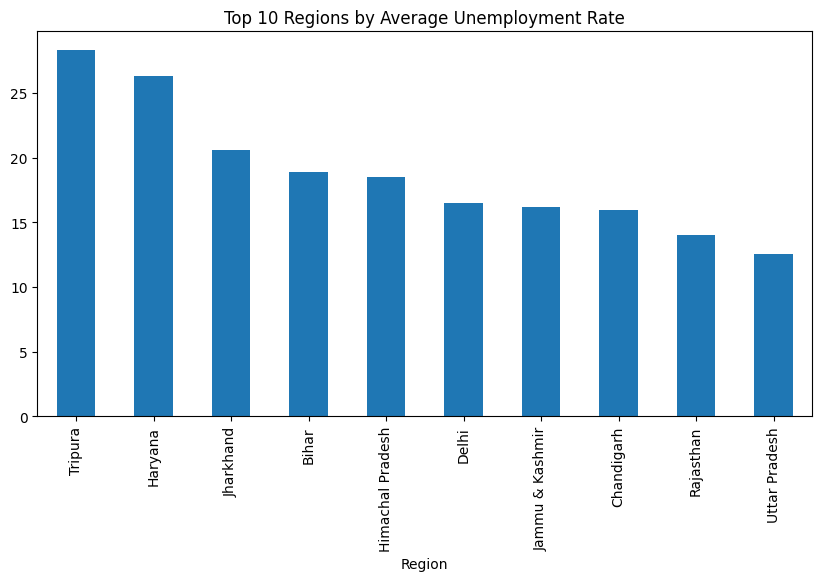

In [20]:
state_unemployment.sort_values(
    ascending=False
).head(10).plot(
    kind='bar',
    figsize=(10,5)
)

plt.title("Top 10 Regions by Average Unemployment Rate")
plt.show()

In [21]:
before_covid = df[
    df['Date'] < '2020-03-01'
]

after_covid = df[
    df['Date'] >= '2020-03-01'
]

In [22]:
print(
    "Before Covid:",
    before_covid[
        'Estimated Unemployment Rate (%)'
    ].mean()
)

print(
    "After Covid:",
    after_covid[
        'Estimated Unemployment Rate (%)'
    ].mean()
)

Before Covid: 9.509533582089553
After Covid: 17.774362745098042


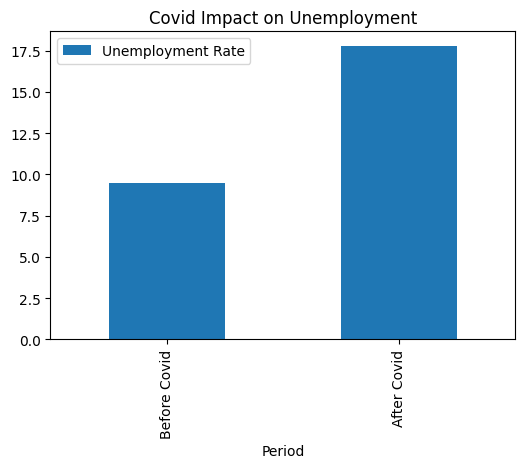

In [23]:
covid_comparison = pd.DataFrame({
    'Period':['Before Covid','After Covid'],
    'Unemployment Rate':[
        before_covid[
            'Estimated Unemployment Rate (%)'
        ].mean(),
        after_covid[
            'Estimated Unemployment Rate (%)'
        ].mean()
    ]
})

covid_comparison.plot(
    x='Period',
    y='Unemployment Rate',
    kind='bar',
    figsize=(6,4)
)

plt.title('Covid Impact on Unemployment')
plt.show()

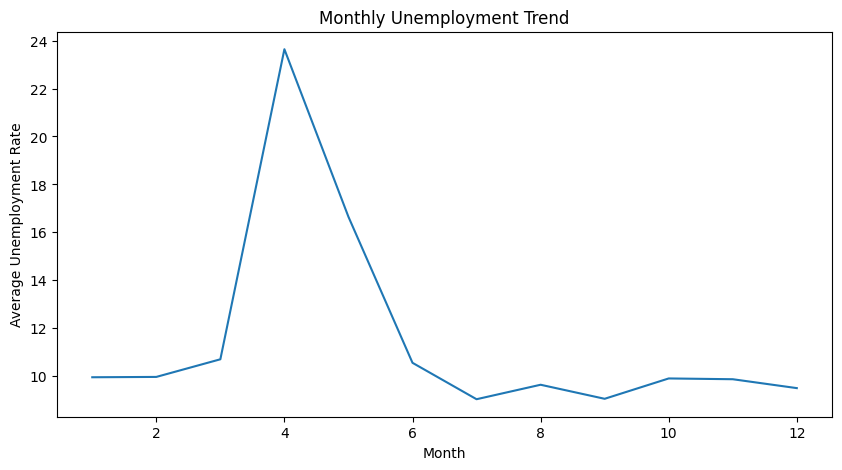

In [24]:
df['Month'] = df['Date'].dt.month

monthly_trend = df.groupby('Month')[
    'Estimated Unemployment Rate (%)'
].mean()

monthly_trend.plot(
    figsize=(10,5)
)

plt.title("Monthly Unemployment Trend")
plt.xlabel("Month")
plt.ylabel("Average Unemployment Rate")

plt.show()